In [1]:
from RAG_model.evaluation.evaluation import main as evaluate
from RAG_model.evaluation.analysis_utils import run_config,plot_retrieval_metrics, plot_retrieval_by_config
from RAG_model.ingestion.config import BASELINE_RUN_CONFIG
from tqdm import tqdm
import pandas as pd 

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

# Baseline Model

#### Params
- k =  12
- Chunk size = 500
- Chunk_Overlap = 120
- Embedding_model = openai - small
- Reranker =  NO
- Retrieval = Hybrid

#### Results
- Document Hit rate = 0.88
- MRR = 0.48



# Iteration over K retrieval 

The hit rate is goo after 10, but we have the best point of balance when we retrieve 15, beyond that we got relevant results with 30, but that means that we are adding more noise to the model.
The MRR keeps being flat at 0.48 for all the K, menaing that ussually the right chunk is retrieve at the 10-12 rank, this is what we will try to focus to improve in the next iterations.

For now we will keep using k=15 as the best result and use it for the next iterations. 

In the generative experiemnts,may we will try to use k=12 to try to improve the results

In [ ]:
retrieval_k = [5,10,12,15,20,30]
summaries_k = pd.DataFrame()
for k in tqdm(retrieval_k):
    print(f"In progress iteration: k_{k}")
    config = run_config(pipeline_version = "v4",retrieval_k= k ,chunk_size=500, chunk_overlap=120)
    config_dict = config.get_dictionary()
    try:
        detailed_questions, summary = await evaluate(config_dict, retrieval_only=True)
        summary['retrieval_k'] = k
        summaries_k = pd.concat([summaries_k,summary], ignore_index=True)
    except Exception as e: 
        print(f"❌ Failed for k={k}: {e}")
        continue
    

  0%|          | 0/6 [00:00<?, ?it/s]

In progress iteration: k_5
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:26<00:00,  1.48it/s] | Complete


 17%|█▋        | 1/6 [00:30<02:30, 30.05s/it]

In progress iteration: k_10
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:25<00:00,  1.59it/s] | Complete


 33%|███▎      | 2/6 [00:56<01:52, 28.03s/it]

...

 67%|██████▋   | 4/6 [01:51<00:55, 27.80s/it]

In progress iteration: k_20
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:30<00:00,  1.33it/s] | Complete


 83%|████████▎ | 5/6 [02:23<00:29, 29.15s/it]

In progress iteration: k_30
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:25<00:00,  1.54it/s] | Complete


100%|██████████| 6/6 [02:50<00:00, 28.49s/it]


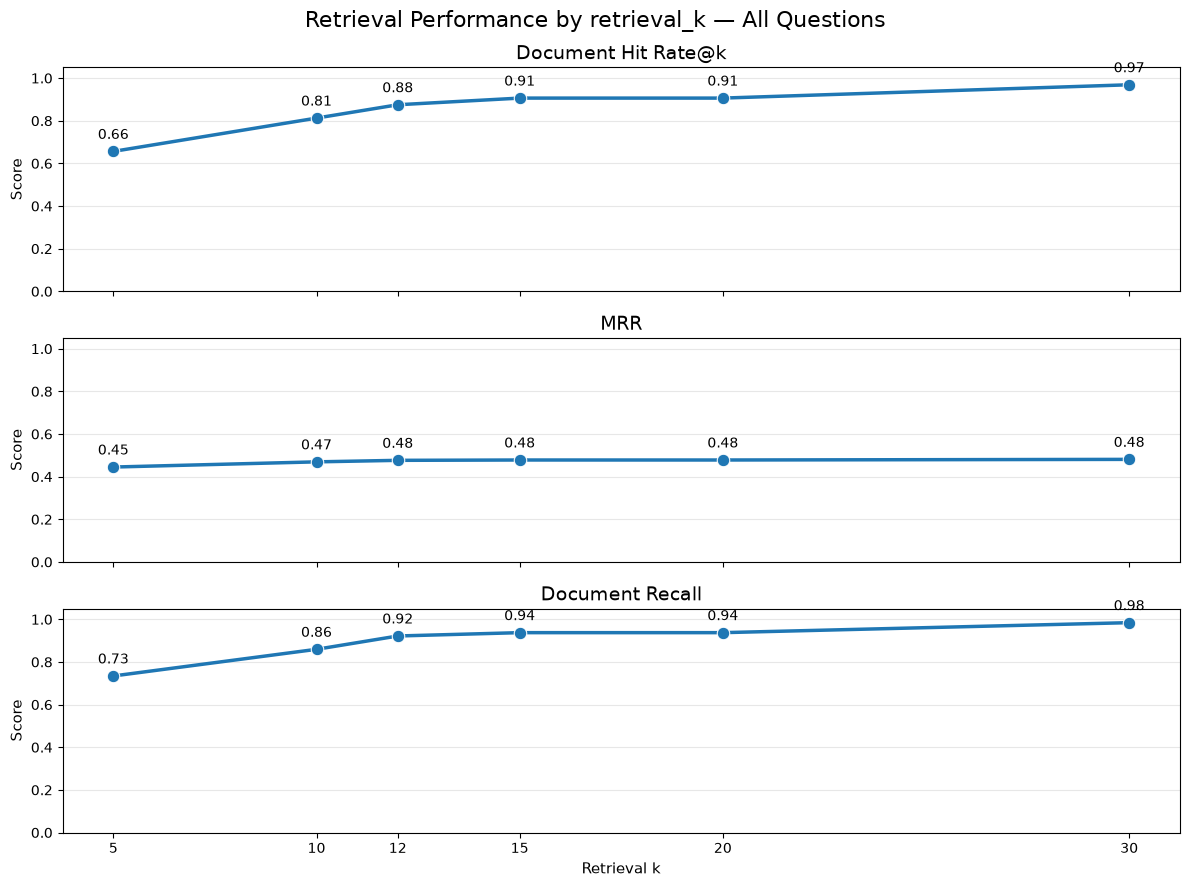

In [3]:
plot_retrieval_metrics(summaries, x_axis="retrieval_k")

# Iteration over chunk Size

We check that the best option is the chunk size of 500 (the one we where using before). But still we have not being able to get an improvement for the MRR.

We will select the 500 size as the best.

Reserve the 500 and 1000 for future iterations


In [11]:
chunk_size = [300,500,800,1000,1200,1500]
summaries_cs = pd.DataFrame()
for size in tqdm(chunk_size):
    print(f"In progress iteration: size {size}")
    config = run_config(pipeline_version = "v4",retrieval_k= 15 ,chunk_size=size, chunk_overlap=120)
    config_dict = config.get_dictionary()
    try:
        detailed_questions, summary = await evaluate(config_dict, retrieval_only=True)
        summary['chunk_size'] = size
        summaries_cs = pd.concat([summaries_cs,summary], ignore_index=True)
    except Exception as e: 
        print(f"❌ Failed for size={size}: {e}")
        continue

  0%|          | 0/6 [00:00<?, ?it/s]

In progress iteration: size 300
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:31<00:00,  1.27it/s] | Complete


 17%|█▋        | 1/6 [00:38<03:11, 38.33s/it]

In progress iteration: size 500
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:24<00:00,  1.66it/s] | Complete


 33%|███▎      | 2/6 [01:09<02:15, 33.84s/it]

...

 67%|██████▋   | 4/6 [01:59<00:56, 28.49s/it]

In progress iteration: size 1200
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:22<00:00,  1.79it/s] | Complete


 83%|████████▎ | 5/6 [02:27<00:28, 28.61s/it]

In progress iteration: size 1500
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:20<00:00,  1.91it/s] | Complete


100%|██████████| 6/6 [02:55<00:00, 29.29s/it]


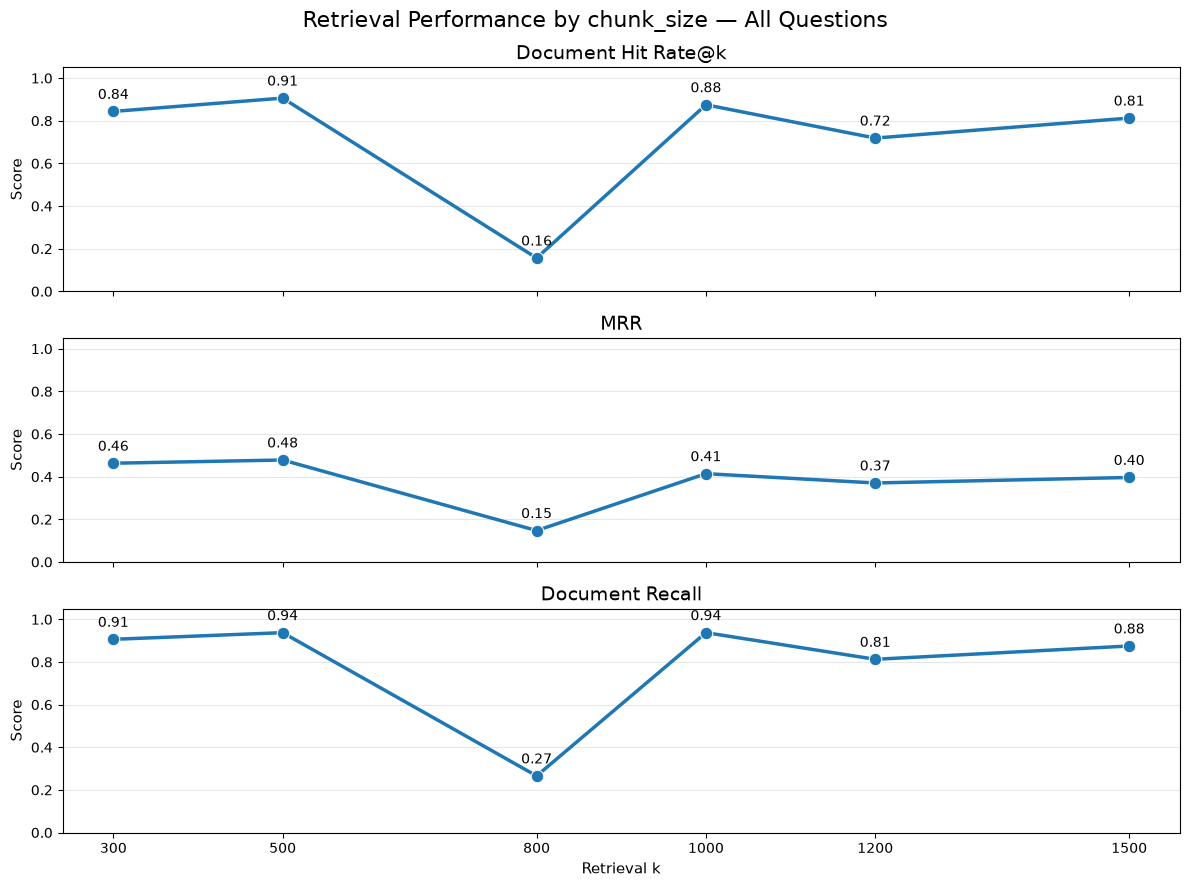

In [13]:
plot_retrieval_metrics(summaries_cs, x_axis="chunk_size")

# Iterations over chunk overlap

Because this is higly correlated with the chunk size we will iterate over the best values selected from before.

In [ ]:
chunk_size = [500]
chunk_overlap = [75,120,150,200]
summaries_overl = pd.DataFrame()
for size in tqdm(chunk_size):
    for overlap in chunk_overlap:
        print(f"In progress iteration: size {size}")
        config = run_config(pipeline_version = "v4",retrieval_k= 15 ,chunk_size=size, chunk_overlap=overlap)
        config_dict = config.get_dictionary()
        try:
            detailed_questions, summary = await evaluate(config_dict, retrieval_only=True)
            summary['chunk_size'] = size
            summary['chunk_overlap'] = overlap
            summaries_overl = pd.concat([summaries_overl,summary], ignore_index=True)
        except Exception as e: 
            print(f"❌ Failed for size={size} and overlap={overlap}: {e}")
            continue
        
summaries_overl.to_csv('summary_overl.csv',index=False)

  0%|          | 0/2 [00:00<?, ?it/s]

In progress iteration: size 500
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:24<00:00,  1.63it/s] | Complete
In progress iteration: size 500
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:24<00:00,  1.67it/s] | Complete
In progress iteration: size 500
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:25<00:00,  1.59it/s] | Complete
In progress iteration: size 500
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:25<00:00,  1.57it/s] | Complete


 50%|█████     | 1/2 [03:26<03:26, 206.03s/it]

In progress iteration: size 1000
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:21<00:00,  1.84it/s] | Complete
In progress iteration: size 1000
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:21<00:00,  1.84it/s] | Complete
In progress iteration: size 1000
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:23<00:00,  1.68it/s] | Complete
In progress iteration: size 1000
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [00:22<00:00,  1.79it/s] | Complete


100%|██████████| 2/2 [06:45<00:00, 202.69s/it]


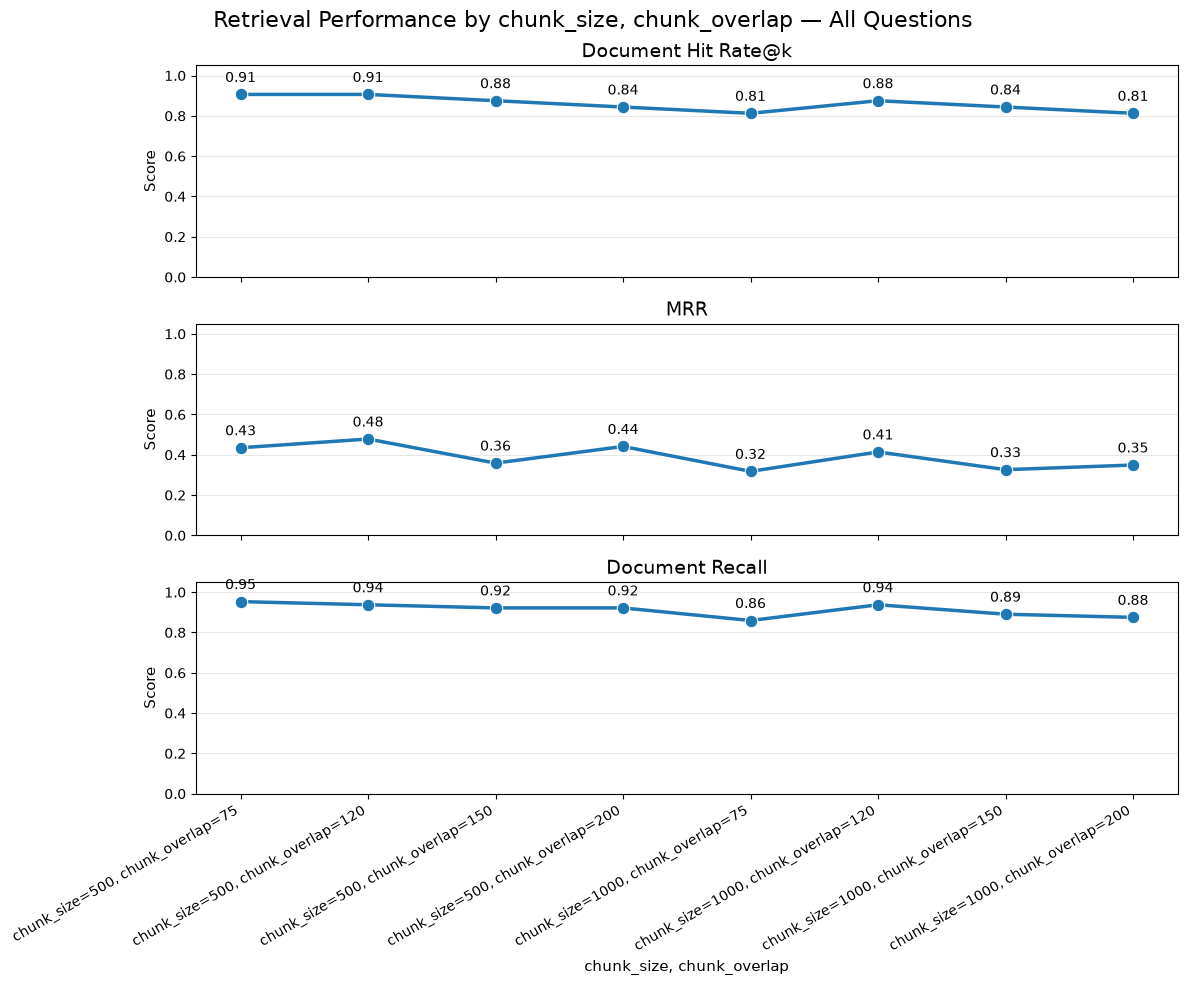

In [5]:
plot_retrieval_by_config(summaries_overl,['chunk_size','chunk_overlap'])

# Iterations over chunk overlap with Rerrank

In [ ]:
chunk_size = [500]
chunk_overlap = [75,120,150,200]
summaries_overl_2 = pd.DataFrame()
for size in tqdm(chunk_size):
    for overlap in chunk_overlap:
        print(f"In progress iteration: size {size} and overlap {overlap}")
        config = run_config(pipeline_version = "v4",retrieval_k= 15 ,chunk_size=size, chunk_overlap=overlap, rerank=True)
        config_dict = config.get_dictionary()
        try:
            detailed_questions, summary = await evaluate(config_dict, retrieval_only=True)
            summary['chunk_size'] = size
            summary['chunk_overlap'] = overlap
            summaries_overl_2 = pd.concat([summaries_overl_2,summary], ignore_index=True)
        except Exception as e: 
            print(f"❌ Failed for size={size} and overlap={overlap}: {e}")
            continue
        
summaries_overl_2.to_csv('summary_overl.csv',index=False)

  0%|          | 0/2 [00:00<?, ?it/s]

In progress iteration: size 500 and overlap 75
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [17:17<00:00, 25.94s/it] | Complete
In progress iteration: size 500 and overlap 120
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [17:26<00:00, 26.16s/it] | Complete
In progress iteration: size 500 and overlap 150
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [17:54<00:00, 26.86s/it] | Complete
In progress iteration: size 500 and overlap 200
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [16:01<00:00, 24.03s/it] | Complete


 50%|█████     | 1/2 [1:10:27<1:10:27, 4227.85s/it]

In progress iteration: size 1000 and overlap 75
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [30:52<00:00, 46.31s/it] | Complete
In progress iteration: size 1000 and overlap 120
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [32:15<00:00, 48.38s/it] | Complete
❌ Failed for size=1000 and overlap=120: [Errno 2] No such file or directory: 'C:\\Users\\david\\Documents\\Projects\\crypto_chatbot_rag\\data\\rag_evaluation\\results\\chunk-1000__overlap-120__embedding-openai-text-embedding-3-small__k-15__generator-openai-gpt-4o-mini__prompt-v2__rerank-BAAI\\bge-reranker-v2-m3\\retrieval_only\\question_results.csv'
In progress iteration: size 1000 and overlap 150
Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [33:24<00:00, 50.12s/it] | Comp

100%|██████████| 2/2 [3:22:08<00:00, 6064.44s/it]  

❌ Failed for size=1000 and overlap=200: [Errno 2] No such file or directory: 'C:\\Users\\david\\Documents\\Projects\\crypto_chatbot_rag\\data\\rag_evaluation\\results\\chunk-1000__overlap-200__embedding-openai-text-embedding-3-small__k-15__generator-openai-gpt-4o-mini__prompt-v2__rerank-BAAI\\bge-reranker-v2-m3\\retrieval_only\\question_results.csv'


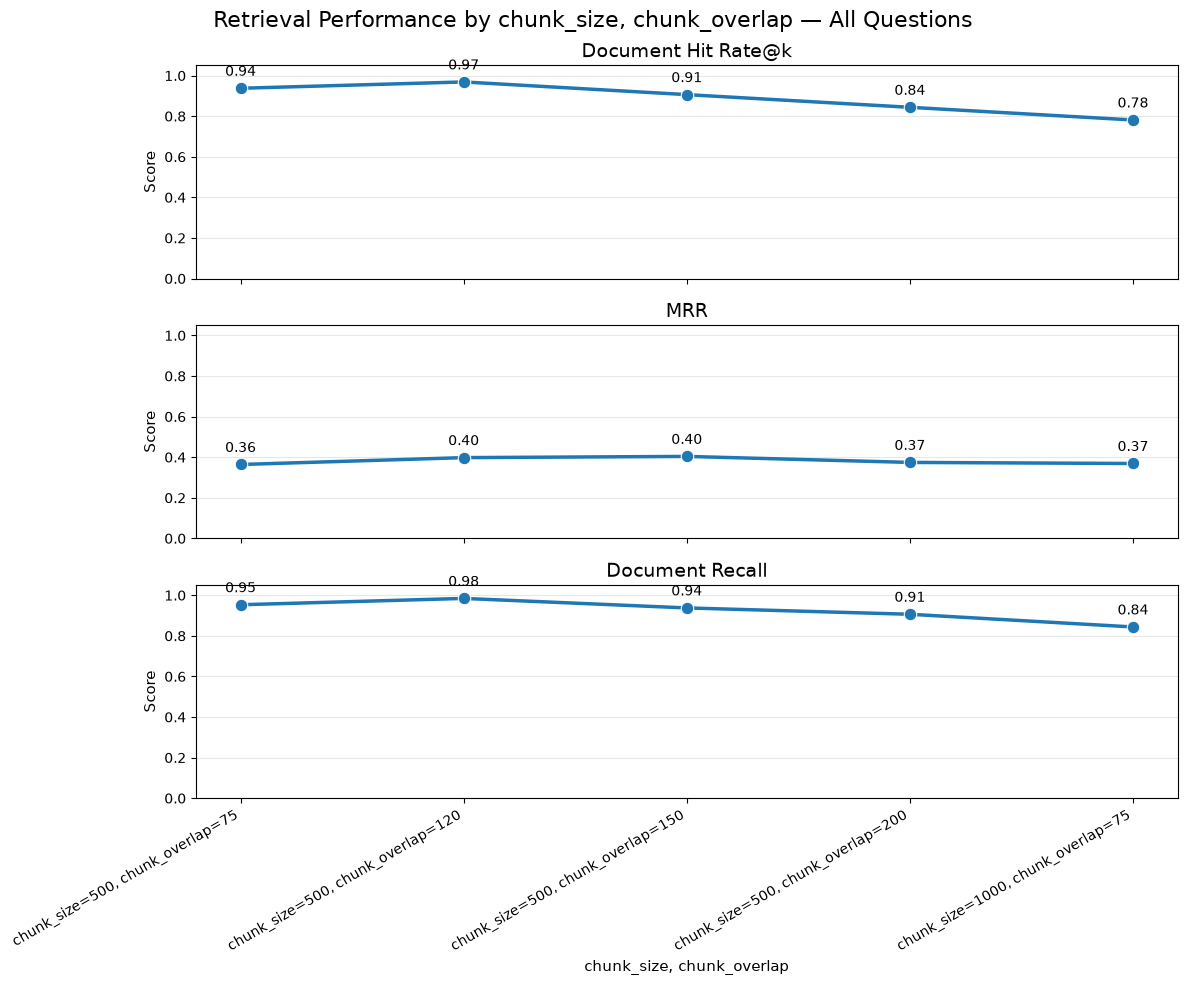

In [4]:
plot_retrieval_by_config(summaries_overl_2,['chunk_size','chunk_overlap'])

In [2]:
config = run_config(pipeline_version = "v6",retrieval_k= 15 ,chunk_size=500, chunk_overlap=120, rerank=False)
config_dict = config.get_dictionary()
detailed_questions_1, summary_1 = await evaluate(config_dict, retrieval_only=False)

Parquet file already exists.
Collection already created.
Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [21:58<00:00, 32.96s/it] | Complete


In [4]:
summary_1

,scope,total_questions,answerable_questions,unanswerable_questions,correct_answers,overall_answer_accuracy,document_hit_rate_at_k,mean_document_recall_at_k,mrr,answerable_correct_answers,answerable_answer_accuracy,citation_validity_rate,mean_ragas_faithfulness,mean_ragas_factual_correctness,mean_ragas_context_precision,abstention_accuracy,mean_total_latency_ms,p95_total_latency_ms,mean_rag_total_tokens,total_rag_tokens
0,All questions,40,32,8,15,0.375000,0.906250,0.937500,0.478088,7,0.218750,0.800000,0.804278,0.548750,0.584242,1.0,2924.755165,4801.354685,8027.300000,321092
1,Hard,21,18,3,6,0.285714,0.888889,0.916667,0.479609,3,0.166667,0.714286,0.753968,0.480556,0.491956,1.0,3081.370448,4891.587300,7871.619048,165304
2,Medium,19,14,5,9,0.473684,0.928571,0.964286,0.476134,4,0.285714,0.894737,0.868963,0.636429,0.702896,1.0,2751.654063,3982.478140,8199.368421,155788


In [3]:
config = run_config(pipeline_version = "v6",retrieval_k= 15 ,chunk_size=500, chunk_overlap=120, rerank=True)
config_dict = config.get_dictionary()
detailed_questions_2, summary_2 = await evaluate(config_dict, retrieval_only=False)

Questions [openai/gpt-4o-mini]: 100%|###############################| 40/40 [41:17<00:00, 61.95s/it] | Complete


In [5]:
summary_2

,scope,total_questions,answerable_questions,unanswerable_questions,correct_answers,overall_answer_accuracy,document_hit_rate_at_k,mean_document_recall_at_k,mrr,answerable_correct_answers,answerable_answer_accuracy,citation_validity_rate,mean_ragas_faithfulness,mean_ragas_factual_correctness,mean_ragas_context_precision,abstention_accuracy,mean_total_latency_ms,p95_total_latency_ms,mean_rag_total_tokens,total_rag_tokens
0,All questions,40,32,8,16,0.400000,0.968750,0.984375,0.397867,8,0.250000,0.675000,0.783673,0.523125,0.613781,1.0,29095.755528,41016.74242,8331.300000,333252
1,Hard,21,18,3,6,0.285714,0.944444,0.972222,0.305467,3,0.166667,0.571429,0.749214,0.465556,0.543637,1.0,29664.337090,40594.18790,8277.761905,173833
2,Medium,19,14,5,10,0.526316,1.000000,1.000000,0.516667,5,0.357143,0.789474,0.827976,0.597143,0.703966,1.0,28467.323274,33443.06222,8390.473684,159419
